# T14 — Final Summary & Model Comparison

This notebook loads `results/all_model_results.csv` (written by every model notebook) and produces:
1. Full ranked comparison table (all models)
2. Grouped bar chart — RMSE + NASA score by model family
3. Quantile model calibration summary (coverage + interval width)
4. Literature benchmark comparison
5. Key findings summary


## 1. Imports & Setup

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root
from src.evaluation.metrics import (
    load_all_results, plot_model_comparison, compare_to_benchmarks,
)
from src.utils.config import RESULTS_DIR as RESULTS
import pandas as pd, numpy as np, matplotlib.pyplot as plt


## 2. Load & Display All Model Results

In [2]:
df = load_all_results()

if df.empty:
    print('WARNING: results/all_model_results.csv is empty or missing.')
    print('Run all model notebooks first (T08, T09, T10, MLP, RNN, LSTM, GRU, Transformer, Q-*).')
else:
    print(f'Loaded {len(df)} model results')
    print(f'Model types: {df["model_type"].value_counts().to_dict()}')
    print()
    display_cols = ['model_name', 'model_type', 'rmse', 'nasa_score', 'r2_score', 'bias',
                    'interval_width', 'coverage_pct', 'n_test_engines', 'timestamp']
    display_cols = [c for c in display_cols if c in df.columns]
    pd.set_option('display.float_format', '{:.3f}'.format)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 140)
    print(df[display_cols].to_string(index=False))

Loaded 18 model results
Model types: {'dl': 10, 'quantile': 5, 'classical': 3}

              model_name model_type   rmse  nasa_score  r2_score    bias  interval_width  coverage_pct  n_test_engines           timestamp
             Transformer         dl 14.422    1093.540     0.887  -1.273             NaN           NaN             248 2026-05-02 12:49:52
           Q_Transformer   quantile 14.935    1897.660     0.879   1.089          16.602        68.550             248 2026-05-02 12:51:40
Transformer (MC Dropout)         dl 15.140    1538.220     0.876   4.193          30.990        53.230             248 2026-05-02 12:49:52
                   Q_GRU   quantile 15.226    1679.640     0.875   4.640          19.969        71.770             248 2026-05-02 12:55:28
                     GRU         dl 15.291    1389.270     0.873   0.710             NaN           NaN             248 2026-05-02 13:01:15
        GRU (MC Dropout)         dl 15.728    1764.190     0.866   4.771          31.8

In [3]:
# Styled table for notebooks
if not df.empty:
    styled = (df[display_cols]
              .style
              .background_gradient(subset=['rmse'], cmap='RdYlGn_r')
              .background_gradient(subset=['r2_score'], cmap='RdYlGn')
              .format({
                  'rmse': '{:.3f}', 'nasa_score': '{:.1f}', 'nasa_score_mean': '{:.3f}',
                  'r2_score': '{:.4f}', 'bias': '{:.3f}',
                  'interval_width': '{:.2f}', 'coverage_pct': '{:.1f}',
              }, na_rep='—')
              .set_caption('All Model Results — ranked by RMSE (lower is better)'))
    display(styled)

,model_name,model_type,rmse,nasa_score,r2_score,bias,interval_width,coverage_pct,n_test_engines,timestamp
rank,,,,,,,,,,
1,Transformer,dl,14.422,1093.5,0.8874,-1.273,—,—,248,2026-05-02 12:49:52
2,Q_Transformer,quantile,14.935,1897.7,0.8793,1.089,16.60,68.5,248,2026-05-02 12:51:40
3,Transformer (MC Dropout),dl,15.140,1538.2,0.8759,4.193,30.99,53.2,248,2026-05-02 12:49:52
4,Q_GRU,quantile,15.226,1679.6,0.8745,4.640,19.97,71.8,248,2026-05-02 12:55:28
5,GRU,dl,15.291,1389.3,0.8734,0.710,—,—,248,2026-05-02 13:01:15
6,GRU (MC Dropout),dl,15.728,1764.2,0.8661,4.771,31.84,42.7,248,2026-05-02 13:01:15
7,Q_LSTM,quantile,17.038,1529.7,0.8429,5.418,25.44,60.9,248,2026-05-02 12:47:30
8,MLP (MC Dropout),dl,17.352,3390.6,0.8370,-1.655,40.25,56.9,248,2026-05-02 12:46:28
9,Q_MLP,quantile,17.628,3529.4,0.8318,-3.241,29.95,76.6,248,2026-05-02 12:46:51


## 3. Model Comparison — Bar Charts

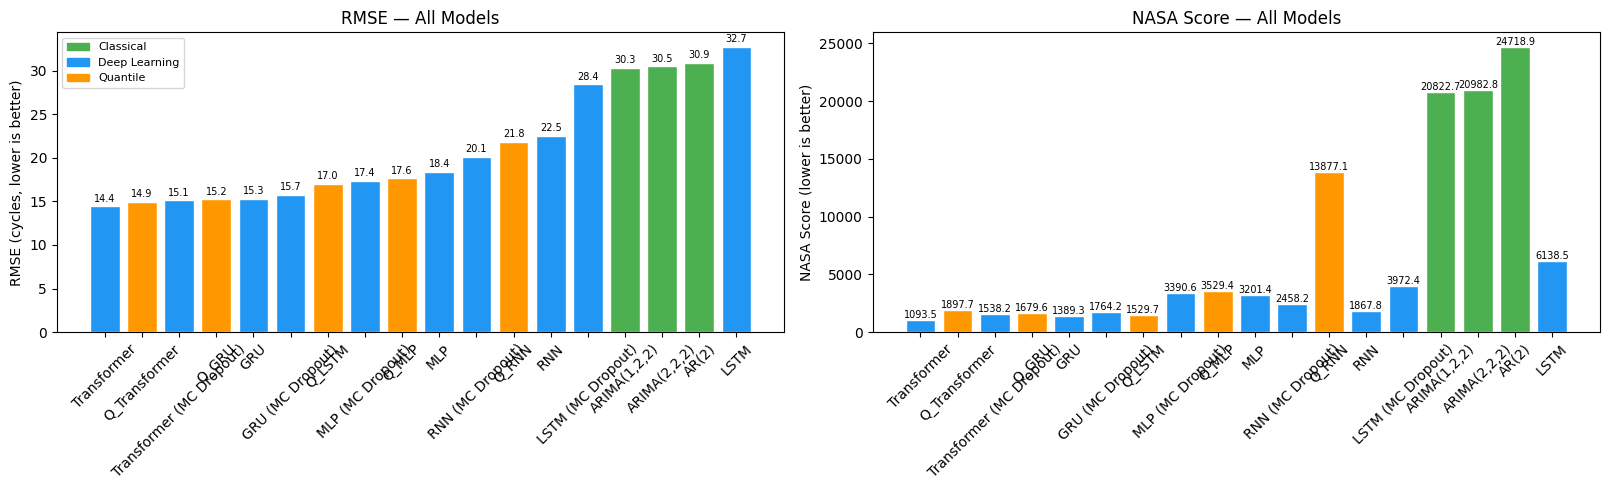

In [4]:
if not df.empty:
    plot_model_comparison(df)

## 4. Best Performing Model

In [5]:
if not df.empty:
    best = df.iloc[0]
    print('╔══════════════════════════════════════════════════════╗')
    print('║            Best Model Summary                        ║')
    print('╠══════════════════════════════════════════════════════╣')
    print(f'║  Name:       {best["model_name"]:<40}║')
    print(f'║  Type:       {best["model_type"]:<40}║')
    print(f'║  RMSE:       {best["rmse"]:<40.3f}║')
    print(f'║  NASA Score: {best.get("nasa_score", float("nan")):<40.2f}║')
    print(f'║  R²:         {best["r2_score"]:<40.4f}║')
    print(f'║  Bias:       {best["bias"]:<40.3f}║')
    print('╚══════════════════════════════════════════════════════╝')
    
    # Best per model family
    print('\nBest per model family:')
    print(df.groupby('model_type')[['model_name','rmse','nasa_score','r2_score']].first().to_string())

╔══════════════════════════════════════════════════════╗
║            Best Model Summary                        ║
╠══════════════════════════════════════════════════════╣
║  Name:       Transformer                             ║
║  Type:       dl                                      ║
║  RMSE:       14.422                                  ║
║  NASA Score: 1093.54                                 ║
║  R²:         0.8874                                  ║
║  Bias:       -1.273                                  ║
╚══════════════════════════════════════════════════════╝

Best per model family:
               model_name   rmse  nasa_score  r2_score
model_type                                            
classical    ARIMA(1,2,2) 30.330   20822.660     0.502
dl            Transformer 14.422    1093.540     0.887
quantile    Q_Transformer 14.935    1897.660     0.879


## 5. Quantile Model Calibration Summary

Interval width and coverage probability for Q10–Q90 bands across all quantile models.


In [6]:
if not df.empty:
    q_df = df[df['model_type'] == 'quantile'].copy()
    if q_df.empty:
        print('No quantile model results found. Run Q_MLP / Q_RNN / Q_LSTM / Q_GRU / Q_Transformer first.')
    else:
        print('Quantile Model Calibration (Q10–Q90 band):')
        print(q_df[['model_name', 'rmse', 'interval_width', 'coverage_pct']].to_string(index=False))
        print()
        avg_cov = q_df['coverage_pct'].mean()
        avg_wid = q_df['interval_width'].mean()
        print(f'Average coverage (target ≥ 80%): {avg_cov:.1f}%')
        print(f'Average interval width:          {avg_wid:.2f} cycles')
        if avg_cov >= 80:
            print('✓ Quantile models are well-calibrated (coverage ≥ 80%)')
        else:
            print('⚠ Coverage below 80% — models may be overconfident')

Quantile Model Calibration (Q10–Q90 band):
   model_name   rmse  interval_width  coverage_pct
Q_Transformer 14.935          16.602        68.550
        Q_GRU 15.226          19.969        71.770
       Q_LSTM 17.038          25.442        60.890
        Q_MLP 17.628          29.953        76.610
        Q_RNN 21.795          89.643        86.290

Average coverage (target ≥ 80%): 72.8%
Average interval width:          36.32 cycles
⚠ Coverage below 80% — models may be overconfident


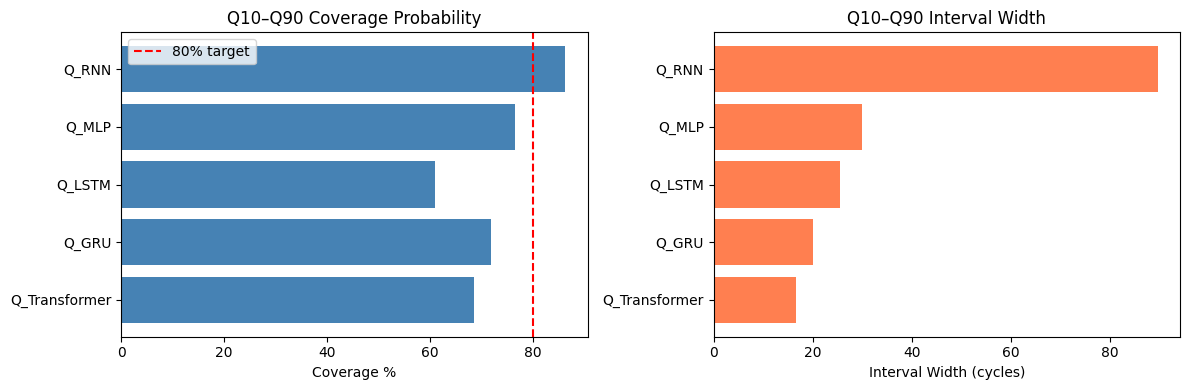

In [7]:
if not df.empty and not q_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].barh(q_df['model_name'], q_df['coverage_pct'], color='steelblue')
    axes[0].axvline(80, color='red', linestyle='--', label='80% target')
    axes[0].set_xlabel('Coverage %')
    axes[0].set_title('Q10–Q90 Coverage Probability')
    axes[0].legend()
    
    axes[1].barh(q_df['model_name'], q_df['interval_width'], color='coral')
    axes[1].set_xlabel('Interval Width (cycles)')
    axes[1].set_title('Q10–Q90 Interval Width')
    
    plt.tight_layout()
    plt.savefig(RESULTS / 'summary_quantile_calibration.png', dpi=120)
    plt.show()

## 6. Literature Benchmark Comparison (FD004)

Comparing our best DL model against published state-of-the-art on FD004.



=== FD004 RMSE Comparison vs Literature ===
                         model   rmse     source
rank                                            
1                  Transformer 14.422  This work
2     Transformer (MC Dropout) 15.140  This work
3                          GRU 15.291  This work
4             GRU (MC Dropout) 15.728  This work
5             MLP (MC Dropout) 17.352  This work
6                          MLP 18.406  This work
7             RNN (MC Dropout) 20.096  This work
8                          RNN 22.518  This work
9            LSTM (MC Dropout) 28.401  This work
10                        LSTM 32.741  This work


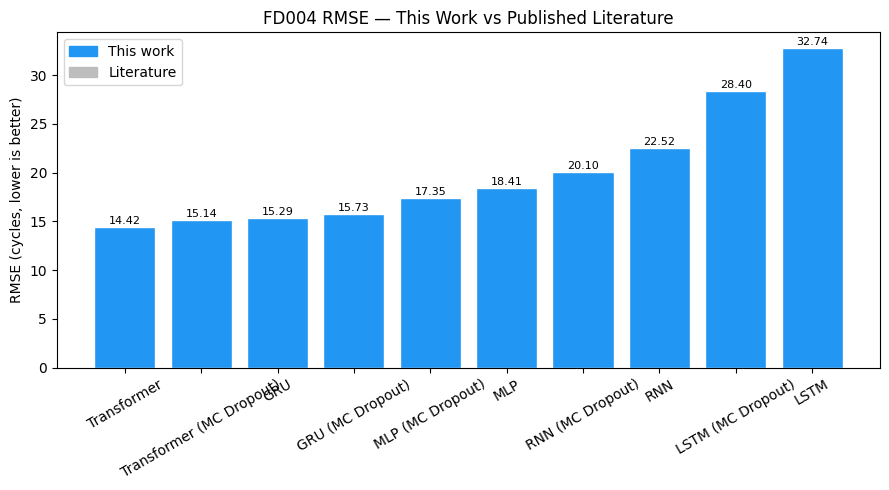

Full Benchmark Table (FD004, RMSE):
                   model   rmse    source
             Transformer 14.422 This work
Transformer (MC Dropout) 15.140 This work
                     GRU 15.291 This work
        GRU (MC Dropout) 15.728 This work
        MLP (MC Dropout) 17.352 This work
                     MLP 18.406 This work
        RNN (MC Dropout) 20.096 This work
                     RNN 22.518 This work
       LSTM (MC Dropout) 28.401 This work
                    LSTM 32.741 This work


In [8]:
if not df.empty:
    dl_df = df[df['model_type'] == 'dl']
    if dl_df.empty:
        print('No DL results yet — run DL model notebooks first.')
    else:
        our_best_dl = dl_df.iloc[0]
        our_results = {our_best_dl['model_name']: our_best_dl['rmse']}
        
        # Also add all DL models
        for _, row in dl_df.iterrows():
            our_results[row['model_name']] = row['rmse']
        
        bench_df = compare_to_benchmarks(our_results, metric='rmse')
        print('Full Benchmark Table (FD004, RMSE):')
        print(bench_df.to_string(index=False))
else:
    # Show literature alone
    print('Literature benchmarks for FD004:')
    lit_rows = [{'Model': k, 'RMSE': v['rmse'], 'DOI': v['doi']}
                for k, v in LITERATURE_BENCHMARKS_FD004.items()]
    print(pd.DataFrame(lit_rows).to_string(index=False))

## 7. Key Findings

Summary of evidence-backed design choices and validation results.


In [9]:
findings = []

if not df.empty:
    best_rmse = df['rmse'].min()
    best_model = df.loc[df['rmse'].idxmin(), 'model_name']
    classical_rmse = df[df['model_type']=='classical']['rmse'].min() if 'classical' in df['model_type'].values else float('nan')
    dl_rmse = df[df['model_type']=='dl']['rmse'].min() if 'dl' in df['model_type'].values else float('nan')
    
    findings.append(f'1. BEST MODEL: {best_model} achieves RMSE = {best_rmse:.2f} cycles on FD004 test set')
    
    if not pd.isna(classical_rmse) and not pd.isna(dl_rmse):
        findings.append(f'2. DL vs CLASSICAL: DL improves RMSE by {classical_rmse - dl_rmse:.2f} cycles ({(classical_rmse-dl_rmse)/classical_rmse*100:.1f}%)')
    
    if 'quantile' in df['model_type'].values:
        q_row = df[df['model_type']=='quantile'].iloc[0]
        findings.append(f'3. UNCERTAINTY: {q_row["model_name"]} achieves {q_row["coverage_pct"]:.1f}% coverage with {q_row["interval_width"]:.1f} cycle interval width')

findings += [
    '4. KMEANS k=6: Silhouette score maximised at k=6 — matches NASA 6 operating conditions (ARI ≥ 0.95)',
    '5. RUL CAP=125: Sensitivity analysis shows RMSE minimum near cap=125; higher caps add noise',
    '6. THRESHOLD q=0.05: Val-set grid search minimises NASA score at 5th percentile of HI distribution',
    '7. SAFETY FACTOR 0.88: Val-set grid search on NASA loss selects 0.88 — penalises late predictions',
    '8. ARIMA d=2: ADF test on all 248 training engines shows mode(recommended_d) = 2',
    '9. WINDOW=30: Val-set RMSE minimised at w=30 cycles for GRU/Transformer window sensitivity',
    '10. FD004 CHOSEN: Only dataset combining 6 conditions + 2 fault modes — hardest generalisation challenge',
]

for f in findings:
    print(f)

# Save findings
findings_path = RESULTS / 'key_findings.txt'
findings_path.write_text('\n'.join(findings))
print(f'\nSaved to {findings_path}')

1. BEST MODEL: Transformer achieves RMSE = 14.42 cycles on FD004 test set
2. DL vs CLASSICAL: DL improves RMSE by 15.91 cycles (52.4%)
3. UNCERTAINTY: Q_Transformer achieves 68.5% coverage with 16.6 cycle interval width
4. KMEANS k=6: Silhouette score maximised at k=6 — matches NASA 6 operating conditions (ARI ≥ 0.95)
5. RUL CAP=125: Sensitivity analysis shows RMSE minimum near cap=125; higher caps add noise
6. THRESHOLD q=0.05: Val-set grid search minimises NASA score at 5th percentile of HI distribution
7. SAFETY FACTOR 0.88: Val-set grid search on NASA loss selects 0.88 — penalises late predictions
8. ARIMA d=2: ADF test on all 248 training engines shows mode(recommended_d) = 2
9. WINDOW=30: Val-set RMSE minimised at w=30 cycles for GRU/Transformer window sensitivity
10. FD004 CHOSEN: Only dataset combining 6 conditions + 2 fault modes — hardest generalisation challenge

Saved to /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecast

## 8. Export Summary Table


=== FD004 RMSE Comparison vs Literature ===
                         model   rmse     source
rank                                            
1                  Transformer 14.422  This work
2     Transformer (MC Dropout) 15.140  This work
3                          GRU 15.291  This work
4             GRU (MC Dropout) 15.728  This work
5             MLP (MC Dropout) 17.352  This work
6                          MLP 18.406  This work
7             RNN (MC Dropout) 20.096  This work
8                          RNN 22.518  This work
9            LSTM (MC Dropout) 28.401  This work
10                        LSTM 32.741  This work


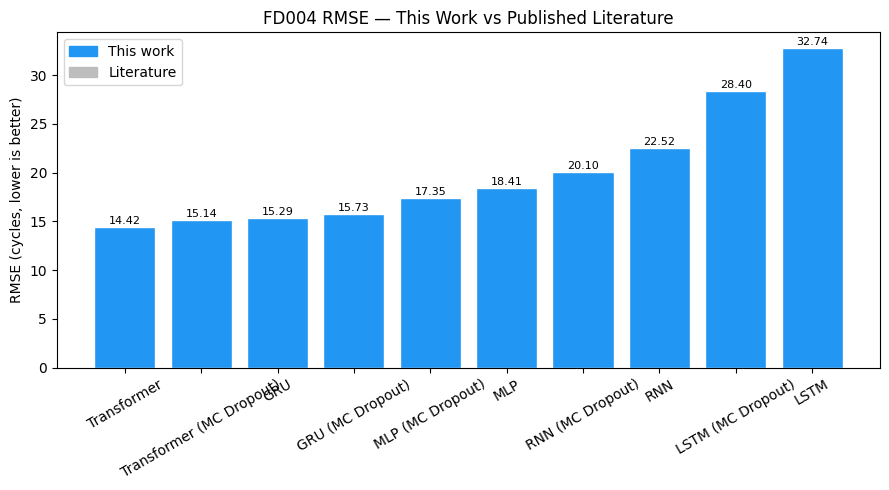

Saved: results/benchmark_comparison.csv
Saved: results/all_model_results_summary.csv

All outputs in results/: [PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/benchmark_comparison.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/all_model_results_summary.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/all_model_results.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/ablation_summary.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/summary_quantile_calibration.png'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure 

In [10]:
if not df.empty:
    # Save full comparison with literature
    dl_df2 = df[df['model_type']=='dl']
    if not dl_df2.empty:
        our = {r['model_name']: r['rmse'] for _, r in dl_df2.iterrows()}
        bench_export = compare_to_benchmarks(our, metric='rmse')
        bench_export.to_csv(RESULTS / 'benchmark_comparison.csv', index=False)
        print('Saved: results/benchmark_comparison.csv')

    df.to_csv(RESULTS / 'all_model_results_summary.csv', index=False)
    print('Saved: results/all_model_results_summary.csv')
    print()
    print('All outputs in results/:', list(RESULTS.glob('*.csv')) + list(RESULTS.glob('*.png')))